In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train/test split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Feature selection
from sklearn.feature_selection import RFECV

# Model used for feature selection
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

# Save models
import joblib

# File handling
import os

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("../data/processed/customer_churn_cleaned.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (50000, 34)


,customer_id,customer_age,gender,city,customer_tenure_months,customer_segment,plan_type,monthly_bill_amount,contract_type,number_of_services,monthly_data_usage_gb,monthly_voice_minutes,monthly_sms_count,international_usage_flag,network_drop_rate,average_download_speed,service_outages_last_6m,support_tickets_last_12m,avg_resolution_time_hours,complaints_last_12m,mobile_app_logins_last_30d,reward_points_balance,campaign_response_rate,late_payments_last_12m,autopay_enabled,billing_disputes_last_12m,customer_lifetime_value,monthly_revenue,retention_offer_count,legacy_customer_code,service_region_cluster,crm_reference_number,marketing_batch_id,churn_flag
0,100000,56,Male,Pune,90,Family,Enterprise,1744.837483,Month-to-Month,1,45.911343,581.834169,78,0,2.235690,NaN,1,0,43.145340,2,12,9408,28.296724,2,1,0,43710.276247,1744.837483,1,682667,32,799034,8963,0
1,100001,69,Female,Hyderabad,73,Family,Enterprise,1191.787428,Month-to-Month,3,30.574466,1205.185406,72,1,0.856839,39.639547,1,3,28.007408,2,19,38319,67.890868,2,1,0,70444.095330,1191.787428,0,266664,34,160389,4153,0
2,100002,46,Female,Delhi,30,Consumer,Prepaid,1301.043042,2 Year,4,36.853273,297.478047,84,1,0.757148,76.607516,1,2,38.026476,3,15,29415,37.944444,2,1,0,67156.246579,1301.043042,0,579857,4,594893,9288,0
3,100003,32,Female,Chennai,108,Consumer,Postpaid,1657.169192,2 Year,1,32.850096,433.856754,69,0,2.418240,56.356062,3,1,21.726140,0,11,41955,NaN,1,1,1,40032.005394,1657.169192,1,434398,45,563518,5734,0
4,100004,60,Female,Delhi,112,Premium,Postpaid,1618.871274,2 Year,5,45.966472,555.242419,76,0,9.319477,NaN,1,2,10.196770,3,14,23221,97.267934,0,0,0,45895.698714,1618.871274,0,893274,19,373531,6535,0


In [3]:
print(df["churn_flag"].value_counts())

print("\nChurn percentage:")
print(df["churn_flag"].value_counts(normalize=True) * 100)

churn_flag
0    36543
1    13457
Name: count, dtype: int64

Churn percentage:
churn_flag
0    73.086
1    26.914
Name: proportion, dtype: float64


In [4]:
X = df.drop(columns=["churn_flag"])
y = df["churn_flag"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 33)
y shape: (50000,)


In [5]:
id_columns = [
    "customer_id",
    "legacy_customer_code",
    "crm_reference_number",
    "marketing_batch_id"
]

existing_id_columns = [
    col for col in id_columns
    if col in X.columns
]

X = X.drop(columns=existing_id_columns)

print("Removed identifier columns:")
print(existing_id_columns)

print("\nRemaining features:")
print(X.columns.tolist())

Removed identifier columns:
['customer_id', 'legacy_customer_code', 'crm_reference_number', 'marketing_batch_id']

Remaining features:
['customer_age', 'gender', 'city', 'customer_tenure_months', 'customer_segment', 'plan_type', 'monthly_bill_amount', 'contract_type', 'number_of_services', 'monthly_data_usage_gb', 'monthly_voice_minutes', 'monthly_sms_count', 'international_usage_flag', 'network_drop_rate', 'average_download_speed', 'service_outages_last_6m', 'support_tickets_last_12m', 'avg_resolution_time_hours', 'complaints_last_12m', 'mobile_app_logins_last_30d', 'reward_points_balance', 'campaign_response_rate', 'late_payments_last_12m', 'autopay_enabled', 'billing_disputes_last_12m', 'customer_lifetime_value', 'monthly_revenue', 'retention_offer_count', 'service_region_cluster']


In [6]:
print("Number of candidate features:", X.shape[1])

for column in X.columns:
    print(column)

Number of candidate features: 29
customer_age
gender
city
customer_tenure_months
customer_segment
plan_type
monthly_bill_amount
contract_type
number_of_services
monthly_data_usage_gb
monthly_voice_minutes
monthly_sms_count
international_usage_flag
network_drop_rate
average_download_speed
service_outages_last_6m
support_tickets_last_12m
avg_resolution_time_hours
complaints_last_12m
mobile_app_logins_last_30d
reward_points_balance
campaign_response_rate
late_payments_last_12m
autopay_enabled
billing_disputes_last_12m
customer_lifetime_value
monthly_revenue
retention_offer_count
service_region_cluster


In [7]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['customer_age', 'customer_tenure_months', 'monthly_bill_amount', 'number_of_services', 'monthly_data_usage_gb', 'monthly_voice_minutes', 'monthly_sms_count', 'international_usage_flag', 'network_drop_rate', 'average_download_speed', 'service_outages_last_6m', 'support_tickets_last_12m', 'avg_resolution_time_hours', 'complaints_last_12m', 'mobile_app_logins_last_30d', 'reward_points_balance', 'campaign_response_rate', 'late_payments_last_12m', 'autopay_enabled', 'billing_disputes_last_12m', 'customer_lifetime_value', 'monthly_revenue', 'retention_offer_count', 'service_region_cluster']

Categorical features:
['gender', 'city', 'customer_segment', 'plan_type', 'contract_type']


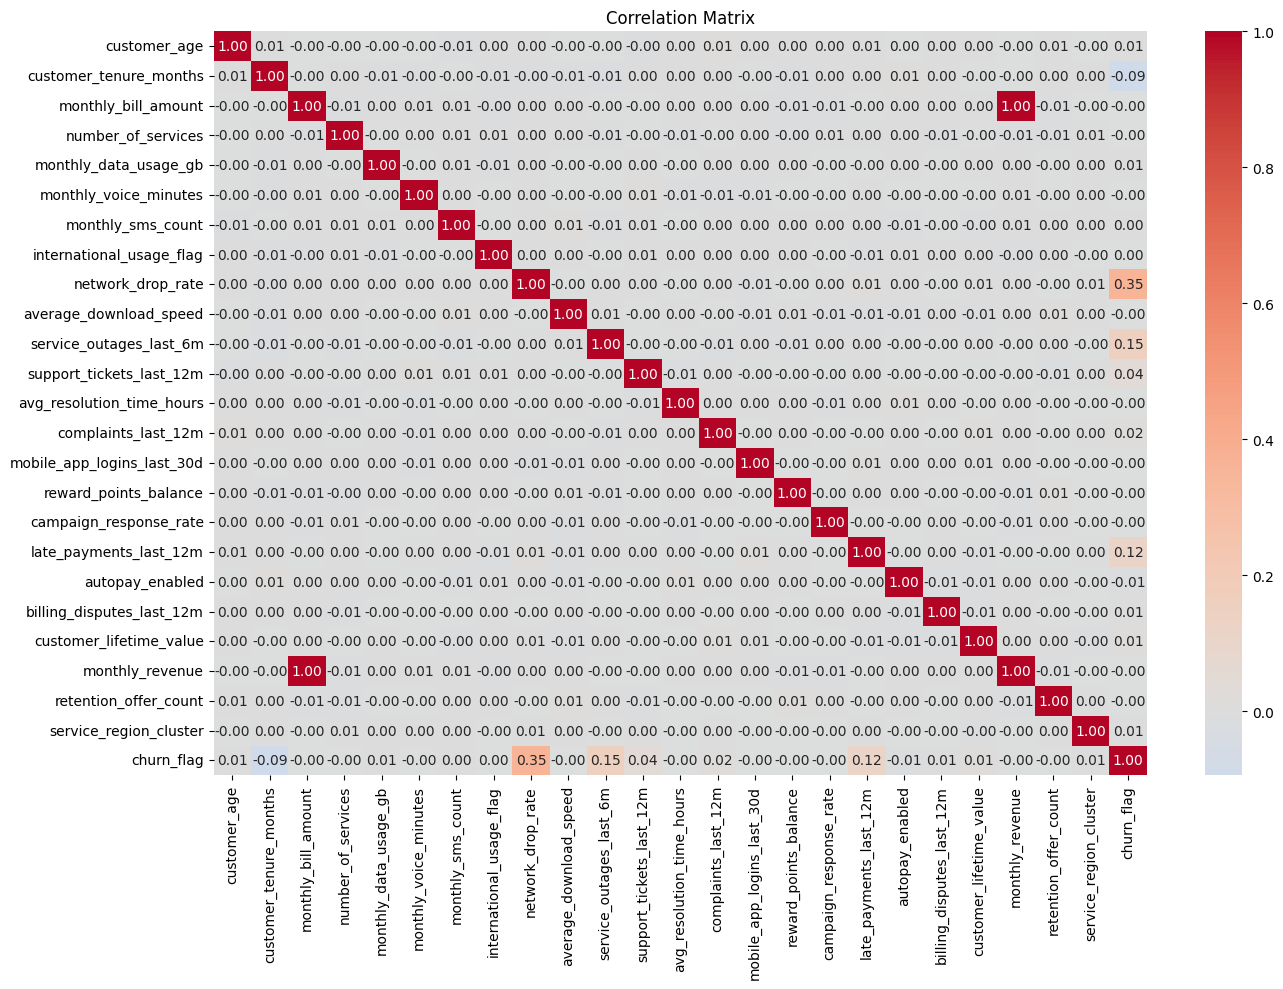

In [8]:
plt.figure(figsize=(14, 10))

correlation_matrix = df[numeric_features + ["churn_flag"]].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [9]:
corr_matrix = df[numeric_features].corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = []

for column in upper_triangle.columns:
    for row in upper_triangle.index:
        value = upper_triangle.loc[row, column]

        if pd.notna(value) and value >= 0.85:
            high_corr_pairs.append(
                (row, column, value)
            )

high_corr_pairs

# This searches for numerical features with correlation ≥ 0.85 because, it's a commonly used practical 
# threshold for identifying potentially redundant numerical variables.

[('monthly_bill_amount', 'monthly_revenue', np.float64(1.0))]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (40000, 29)
Testing set: (10000, 29)


In [11]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [12]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [13]:
#Transformers
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [14]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (40000, 46)
Processed testing shape: (10000, 46)


In [15]:
feature_names = preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))

print("\nFirst 30 transformed features:")
print(feature_names[:30])

Number of transformed features: 46

First 30 transformed features:
['num__customer_age' 'num__customer_tenure_months'
 'num__monthly_bill_amount' 'num__number_of_services'
 'num__monthly_data_usage_gb' 'num__monthly_voice_minutes'
 'num__monthly_sms_count' 'num__international_usage_flag'
 'num__network_drop_rate' 'num__average_download_speed'
 'num__service_outages_last_6m' 'num__support_tickets_last_12m'
 'num__avg_resolution_time_hours' 'num__complaints_last_12m'
 'num__mobile_app_logins_last_30d' 'num__reward_points_balance'
 'num__campaign_response_rate' 'num__late_payments_last_12m'
 'num__autopay_enabled' 'num__billing_disputes_last_12m'
 'num__customer_lifetime_value' 'num__monthly_revenue'
 'num__retention_offer_count' 'num__service_region_cluster'
 'cat__gender_Female' 'cat__gender_Male' 'cat__city_Bangalore'
 'cat__city_Chennai' 'cat__city_Delhi' 'cat__city_Hyderabad']


In [16]:
# Recursive Feature Elimination with Cross-Validation (RFECV) feature selection
logistic_selector = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    max_iter=2000,
    random_state=42
)

rfecv = RFECV(
    estimator=logistic_selector,
    step=1,
    cv=5,
    scoring="f1",
    min_features_to_select=5,
    n_jobs=-1
)

In [17]:
rfecv.fit(X_train_processed, y_train)

print("Optimal number of features:")
print(rfecv.n_features_)

Optimal number of features:
15


In [18]:
# After recursively eliminating features and evaluating the model using 5-fold cross-validation with F1 as the scoring metric, the optimal feature subset containes 15 transformed features
feature_ranking = pd.DataFrame({
    "feature": feature_names,
    "selected": rfecv.support_,
    "ranking": rfecv.ranking_
})

feature_ranking = feature_ranking.sort_values(
    by=["selected", "ranking"],
    ascending=[False, True]
)

feature_ranking.head(50)

,feature,selected,ranking
1,num__customer_tenure_months,True,1
8,num__network_drop_rate,True,1
10,num__service_outages_last_6m,True,1
11,num__support_tickets_last_12m,True,1
17,num__late_payments_last_12m,True,1
24,cat__gender_Female,True,1
25,cat__gender_Male,True,1
33,cat__customer_segment_Business,True,1
34,cat__customer_segment_Consumer,True,1
35,cat__customer_segment_Family,True,1


In [19]:
selected_features_transformed = feature_names[
    rfecv.support_
]

dropped_features_transformed = feature_names[
    ~rfecv.support_
]

print("SELECTED FEATURES")
print("=================")

for feature in selected_features_transformed:
    print("✓", feature)

print("\nDROPPED FEATURES")
print("================")

for feature in dropped_features_transformed:
    print("✗", feature)

SELECTED FEATURES
✓ num__customer_tenure_months
✓ num__network_drop_rate
✓ num__service_outages_last_6m
✓ num__support_tickets_last_12m
✓ num__late_payments_last_12m
✓ cat__gender_Female
✓ cat__gender_Male
✓ cat__customer_segment_Business
✓ cat__customer_segment_Consumer
✓ cat__customer_segment_Family
✓ cat__customer_segment_Premium
✓ cat__plan_type_Prepaid
✓ cat__contract_type_1 Year
✓ cat__contract_type_2 Year
✓ cat__contract_type_Month-to-Month

DROPPED FEATURES
✗ num__customer_age
✗ num__monthly_bill_amount
✗ num__number_of_services
✗ num__monthly_data_usage_gb
✗ num__monthly_voice_minutes
✗ num__monthly_sms_count
✗ num__international_usage_flag
✗ num__average_download_speed
✗ num__avg_resolution_time_hours
✗ num__complaints_last_12m
✗ num__mobile_app_logins_last_30d
✗ num__reward_points_balance
✗ num__campaign_response_rate
✗ num__autopay_enabled
✗ num__billing_disputes_last_12m
✗ num__customer_lifetime_value
✗ num__monthly_revenue
✗ num__retention_offer_count
✗ num__service_regio

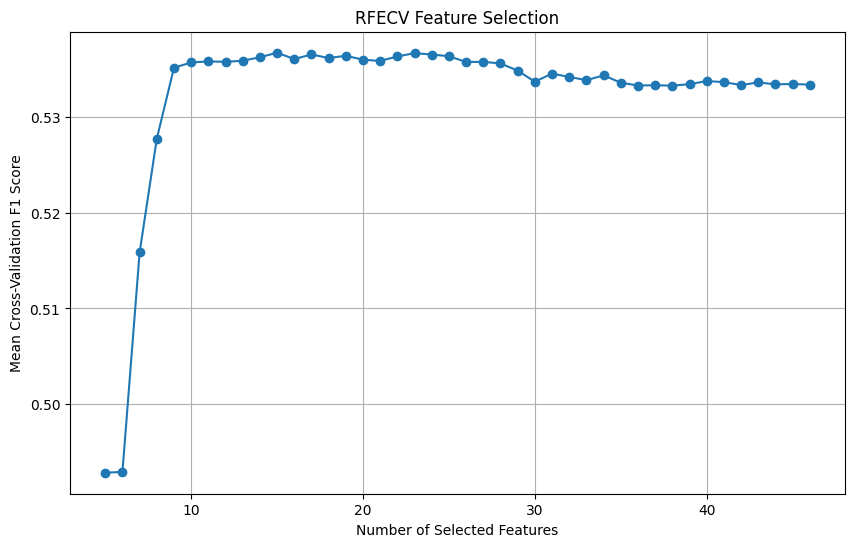

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(
        rfecv.min_features_to_select,
        rfecv.min_features_to_select
        + len(rfecv.cv_results_["mean_test_score"])
    ),
    rfecv.cv_results_["mean_test_score"],
    marker="o"
)

plt.xlabel("Number of Selected Features")
plt.ylabel("Mean Cross-Validation F1 Score")
plt.title("RFECV Feature Selection")
plt.grid(True)

plt.show()

In [21]:
rfecv_coefficients = rfecv.estimator_.coef_[0]

importance_df = pd.DataFrame({
    "feature": selected_features_transformed,
    "coefficient": rfecv_coefficients,
    "absolute_importance": np.abs(rfecv_coefficients)
})

importance_df = importance_df.sort_values(
    "absolute_importance",
    ascending=False
)

importance_df.head(20)

# Positive coefficient: associated with increased probability of churn.
# Negative coefficient: associated with decreased probability of churn.

,feature,coefficient,absolute_importance
1,num__network_drop_rate,1.060058,1.060058
13,cat__contract_type_2 Year,-0.861277,0.861277
14,cat__contract_type_Month-to-Month,0.825062,0.825062
12,cat__contract_type_1 Year,-0.810736,0.810736
2,num__service_outages_last_6m,0.454292,0.454292
5,cat__gender_Female,-0.433270,0.433270
6,cat__gender_Male,-0.413680,0.413680
4,num__late_payments_last_12m,0.320217,0.320217
0,num__customer_tenure_months,-0.280245,0.280245
8,cat__customer_segment_Consumer,-0.235269,0.235269


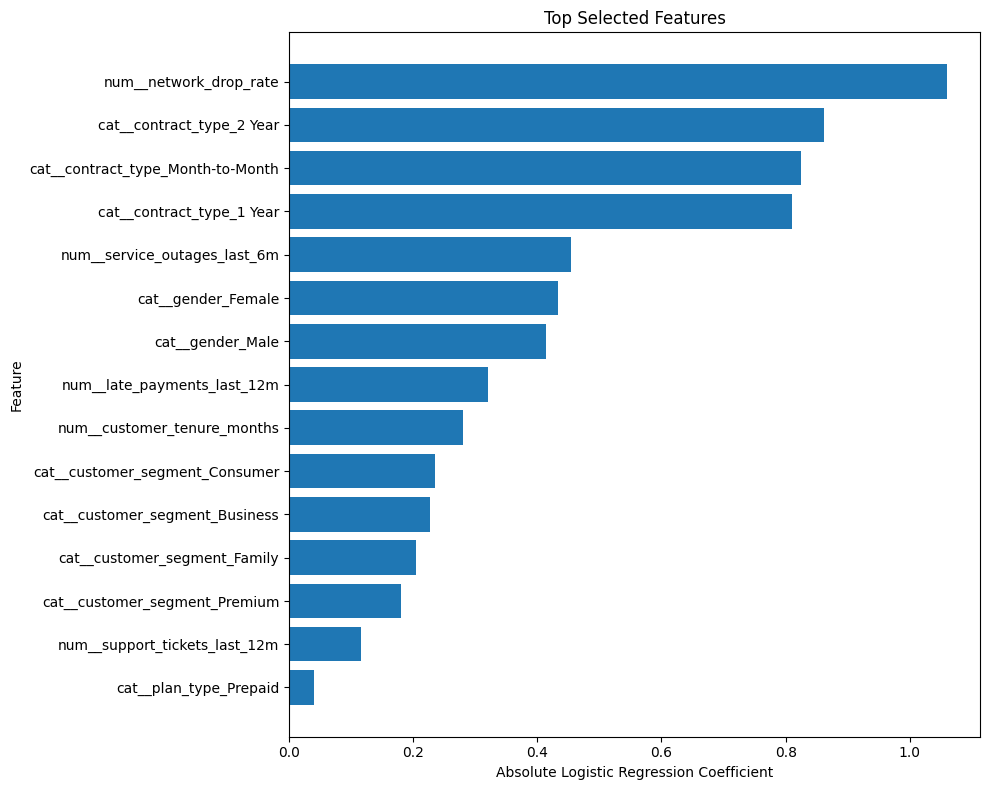

In [22]:
top_features = importance_df.head(20).sort_values(
    "absolute_importance"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"],
    top_features["absolute_importance"]
)

plt.xlabel("Absolute Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Selected Features")

plt.tight_layout()
plt.show()

In [23]:
# Map transformed features to original features
def get_original_feature(transformed_feature):
    
    if transformed_feature.startswith("num__"):
        return transformed_feature.replace("num__", "")
    
    if transformed_feature.startswith("cat__"):
        feature = transformed_feature.replace("cat__", "")
        
        for original_feature in categorical_features:
            if feature.startswith(original_feature + "_"):
                return original_feature
        
        return feature
    
    return transformed_feature


feature_mapping = pd.DataFrame({
    "transformed_feature": feature_names
})

feature_mapping["original_feature"] = (
    feature_mapping["transformed_feature"]
    .apply(get_original_feature)
)

feature_mapping["selected"] = rfecv.support_

feature_mapping.head(30)

,transformed_feature,original_feature,selected
0,num__customer_age,customer_age,False
1,num__customer_tenure_months,customer_tenure_months,True
2,num__monthly_bill_amount,monthly_bill_amount,False
3,num__number_of_services,number_of_services,False
4,num__monthly_data_usage_gb,monthly_data_usage_gb,False
5,num__monthly_voice_minutes,monthly_voice_minutes,False
6,num__monthly_sms_count,monthly_sms_count,False
7,num__international_usage_flag,international_usage_flag,False
8,num__network_drop_rate,network_drop_rate,True
9,num__average_download_speed,average_download_speed,False


In [24]:
original_feature_report = (
    feature_mapping
    .groupby("original_feature")
    .agg(
        transformed_features=("transformed_feature", "count"),
        selected_transformed_features=("selected", "sum")
    )
    .reset_index()
)

original_feature_report["selection_percentage"] = (
    original_feature_report["selected_transformed_features"]
    /
    original_feature_report["transformed_features"]
    * 100
)

original_feature_report

,original_feature,transformed_features,selected_transformed_features,selection_percentage
0,autopay_enabled,1,0,0.000000
1,average_download_speed,1,0,0.000000
2,avg_resolution_time_hours,1,0,0.000000
3,billing_disputes_last_12m,1,0,0.000000
4,campaign_response_rate,1,0,0.000000
5,city,7,0,0.000000
6,complaints_last_12m,1,0,0.000000
7,contract_type,3,3,100.000000
8,customer_age,1,0,0.000000
9,customer_lifetime_value,1,0,0.000000


In [25]:
def feature_decision(row):
    if row["selected_transformed_features"] == 0:
        return "DROP"
    elif (
        row["selected_transformed_features"]
        == row["transformed_features"]
    ):
        return "KEEP"
    else:
        return "PARTIALLY SELECTED"


original_feature_report["decision"] = (
    original_feature_report.apply(
        feature_decision,
        axis=1
    )
)

original_feature_report

,original_feature,transformed_features,selected_transformed_features,selection_percentage,decision
0,autopay_enabled,1,0,0.000000,DROP
1,average_download_speed,1,0,0.000000,DROP
2,avg_resolution_time_hours,1,0,0.000000,DROP
3,billing_disputes_last_12m,1,0,0.000000,DROP
4,campaign_response_rate,1,0,0.000000,DROP
5,city,7,0,0.000000,DROP
6,complaints_last_12m,1,0,0.000000,DROP
7,contract_type,3,3,100.000000,KEEP
8,customer_age,1,0,0.000000,DROP
9,customer_lifetime_value,1,0,0.000000,DROP


In [26]:
os.makedirs("../reports", exist_ok=True)

original_feature_report.to_csv(
    "../reports/feature_selection_report.csv",
    index=False
)

importance_df.to_csv(
    "../reports/selected_feature_importance.csv",
    index=False
)

feature_ranking.to_csv(
    "../reports/rfecv_feature_ranking.csv",
    index=False
)

print("Feature-selection reports saved.")

Feature-selection reports saved.


In [27]:
# ============================================================
# SAVE EXPERIMENT 1 SELECTOR
# ============================================================

joblib.dump(
    rfecv,
    "../models/rfecv_selector.pkl"
)

print(
    "Experiment 1 selector saved."
)

Experiment 1 selector saved.


In [28]:
# ============================================================
# EXPERIMENT 2A
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf_selector = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_selector.fit(
    X_train_processed,
    y_train
)

rf_importance = pd.Series(
    rf_selector.feature_importances_,
    index=feature_names
).sort_values(
    ascending=False
)

rf_importance.head(20)

num__network_drop_rate               0.235845
num__customer_tenure_months          0.058048
cat__contract_type_Month-to-Month    0.054279
num__service_outages_last_6m         0.053532
num__late_payments_last_12m          0.034289
num__avg_resolution_time_hours       0.032935
num__monthly_voice_minutes           0.032550
num__customer_lifetime_value         0.032419
num__monthly_data_usage_gb           0.032272
num__reward_points_balance           0.032243
num__average_download_speed          0.031811
num__campaign_response_rate          0.031569
num__monthly_revenue                 0.029179
num__monthly_bill_amount             0.028951
num__customer_age                    0.027639
num__service_region_cluster          0.026694
num__monthly_sms_count               0.026311
num__mobile_app_logins_last_30d      0.022522
cat__contract_type_1 Year            0.022275
num__support_tickets_last_12m        0.019858
dtype: float64

In [29]:
# ============================================================
# EXPERIMENT 2B
# XGBOOST FEATURE IMPORTANCE
# ============================================================

xgb_selector = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_selector.fit(
    X_train_processed,
    y_train
)

xgb_importance = pd.Series(
    xgb_selector.feature_importances_,
    index=feature_names
).sort_values(
    ascending=False
)

xgb_importance.head(20)

cat__contract_type_Month-to-Month    0.258148
num__network_drop_rate               0.230909
num__service_outages_last_6m         0.103826
num__late_payments_last_12m          0.047530
num__customer_tenure_months          0.036564
num__support_tickets_last_12m        0.020768
num__complaints_last_12m             0.014717
cat__plan_type_POSTPAID              0.010864
cat__plan_type_Unlimited             0.010107
num__avg_resolution_time_hours       0.008931
num__campaign_response_rate          0.008603
num__monthly_data_usage_gb           0.008556
cat__customer_segment_Consumer       0.008347
num__customer_lifetime_value         0.008342
num__autopay_enabled                 0.008315
num__international_usage_flag        0.008187
cat__city_Mumbai                     0.008175
cat__city_Delhi                      0.008108
cat__gender_Female                   0.008016
num__mobile_app_logins_last_30d      0.008001
dtype: float32

In [30]:
# ============================================================
# EXPERIMENT 2 - TOP FEATURES
# ============================================================

N_FEATURES = rfecv.n_features_

rf_top = set(
    rf_importance.head(N_FEATURES).index
)

xgb_top = set(
    xgb_importance.head(N_FEATURES).index
)

print("RF top features:", len(rf_top))
print("XGB top features:", len(xgb_top))

RF top features: 15
XGB top features: 15


In [31]:
# ============================================================
# EXPERIMENT 2 - TREE CONSENSUS
# ============================================================

tree_scores = pd.DataFrame({
    "RandomForest": rf_importance,
    "XGBoost": xgb_importance
})

tree_scores["RF_selected"] = (
    tree_scores.index.isin(rf_top)
    .astype(int)
)

tree_scores["XGB_selected"] = (
    tree_scores.index.isin(xgb_top)
    .astype(int)
)

tree_scores["tree_votes"] = (
    tree_scores["RF_selected"]
    +
    tree_scores["XGB_selected"]
)

tree_scores = tree_scores.sort_values(
    by=[
        "tree_votes",
        "RandomForest",
        "XGBoost"
    ],
    ascending=False
)

tree_scores.head(20)

,RandomForest,XGBoost,RF_selected,XGB_selected,tree_votes
num__network_drop_rate,0.235845,0.230909,1,1,2
num__customer_tenure_months,0.058048,0.036564,1,1,2
cat__contract_type_Month-to-Month,0.054279,0.258148,1,1,2
num__service_outages_last_6m,0.053532,0.103826,1,1,2
num__late_payments_last_12m,0.034289,0.047530,1,1,2
num__avg_resolution_time_hours,0.032935,0.008931,1,1,2
num__customer_lifetime_value,0.032419,0.008342,1,1,2
num__monthly_data_usage_gb,0.032272,0.008556,1,1,2
num__campaign_response_rate,0.031569,0.008603,1,1,2
num__monthly_voice_minutes,0.032550,0.007927,1,0,1


In [32]:
# ============================================================
# EXPERIMENT 2 - FINAL FEATURE SET
# ============================================================

exp2_features = (
    tree_scores
    .head(N_FEATURES)
    .index
    .tolist()
)

print(
    "Experiment 2 selected:",
    len(exp2_features)
)

for feature in exp2_features:
    print(feature)

Experiment 2 selected: 15
num__network_drop_rate
num__customer_tenure_months
cat__contract_type_Month-to-Month
num__service_outages_last_6m
num__late_payments_last_12m
num__avg_resolution_time_hours
num__customer_lifetime_value
num__monthly_data_usage_gb
num__campaign_response_rate
num__monthly_voice_minutes
num__reward_points_balance
num__average_download_speed
num__monthly_revenue
num__monthly_bill_amount
num__customer_age


In [33]:
# ============================================================
# EXPERIMENT 3A - VALIDATION SPLIT
# ============================================================

X_fs_train, X_fs_valid, y_fs_train, y_fs_valid = train_test_split(
    X_train_processed,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

xgb_perm_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_perm_model.fit(
    X_fs_train,
    y_fs_train
)

permutation = permutation_importance(
    xgb_perm_model,
    X_fs_valid,
    y_fs_valid,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

permutation_importance_series = pd.Series(
    permutation.importances_mean,
    index=feature_names
).sort_values(
    ascending=False
)

permutation_importance_series.head(20)

num__network_drop_rate               2.079357e-01
cat__contract_type_Month-to-Month    1.100736e-01
num__service_outages_last_6m         4.418060e-02
num__customer_tenure_months          3.651258e-02
num__late_payments_last_12m          3.114220e-02
num__support_tickets_last_12m        8.867042e-03
cat__contract_type_2 Year            1.347941e-03
num__retention_offer_count           1.173358e-03
cat__customer_segment_Consumer       8.053714e-04
cat__city_Chennai                    5.785024e-04
cat__customer_segment_Family         3.967022e-04
cat__city_Hyderabad                  3.646855e-04
num__monthly_bill_amount             3.516177e-04
cat__gender_Male                     0.000000e+00
num__monthly_revenue                 0.000000e+00
cat__city_Pune                      -3.323859e-08
cat__city_Bangalore                 -6.190600e-05
cat__plan_type_postpaid             -1.640325e-04
cat__city_Delhi                     -1.951840e-04
cat__plan_type_POSTPAID             -2.351998e-04


In [34]:
# ============================================================
# EXPERIMENT 3 - CONSENSUS TABLE
# ============================================================

consensus = pd.DataFrame(
    index=feature_names
)

consensus["rf_rank"] = (
    rf_importance.rank(
        ascending=False,
        method="min"
    )
)

consensus["xgb_rank"] = (
    xgb_importance.rank(
        ascending=False,
        method="min"
    )
)

consensus["permutation_rank"] = (
    permutation_importance_series.rank(
        ascending=False,
        method="min"
    )
)

consensus["rfecv_selected"] = (
    rfecv.support_.astype(int)
)

consensus["rf_selected"] = (
    consensus["rf_rank"] <= N_FEATURES
).astype(int)

consensus["xgb_selected"] = (
    consensus["xgb_rank"] <= N_FEATURES
).astype(int)

consensus["permutation_selected"] = (
    consensus["permutation_rank"] <= N_FEATURES
).astype(int)

In [35]:
# ============================================================
# FINAL CONSENSUS SCORE
# ============================================================

consensus["consensus_score"] = (
    consensus["rfecv_selected"]
    + consensus["rf_selected"]
    + consensus["xgb_selected"]
    + consensus["permutation_selected"]
)

consensus = consensus.sort_values(
    by=[
        "consensus_score",
        "rf_rank",
        "xgb_rank",
        "permutation_rank"
    ],
    ascending=[
        False,
        True,
        True,
        True
    ]
)

consensus.head(20)

,rf_rank,xgb_rank,permutation_rank,rfecv_selected,rf_selected,xgb_selected,permutation_selected,consensus_score
num__network_drop_rate,1.0,2.0,1.0,1,1,1,1,4
num__customer_tenure_months,2.0,5.0,4.0,1,1,1,1,4
cat__contract_type_Month-to-Month,3.0,1.0,2.0,1,1,1,1,4
num__service_outages_last_6m,4.0,3.0,3.0,1,1,1,1,4
num__late_payments_last_12m,5.0,4.0,5.0,1,1,1,1,4
num__support_tickets_last_12m,20.0,6.0,6.0,1,0,1,1,3
cat__customer_segment_Consumer,32.0,13.0,9.0,1,0,1,1,3
num__avg_resolution_time_hours,6.0,10.0,42.0,0,1,1,0,2
num__customer_lifetime_value,8.0,14.0,34.0,0,1,1,0,2
num__monthly_data_usage_gb,9.0,12.0,23.0,0,1,1,0,2


In [36]:
# ============================================================
# EXPERIMENT 3 - FINAL FEATURE SET
# ============================================================

exp3_features = (
    consensus
    .head(N_FEATURES)
    .index
    .tolist()
)

print(
    "Experiment 3 selected:",
    len(exp3_features)
)

for feature in exp3_features:
    print(feature)

Experiment 3 selected: 15
num__network_drop_rate
num__customer_tenure_months
cat__contract_type_Month-to-Month
num__service_outages_last_6m
num__late_payments_last_12m
num__support_tickets_last_12m
cat__customer_segment_Consumer
num__avg_resolution_time_hours
num__customer_lifetime_value
num__monthly_data_usage_gb
num__campaign_response_rate
num__monthly_revenue
num__monthly_bill_amount
cat__contract_type_2 Year
cat__gender_Male


In [37]:
# ============================================================
# FEATURE NAME → COLUMN INDEX
# ============================================================

feature_to_index = {
    feature: index
    for index, feature
    in enumerate(feature_names)
}

exp1_indices = [
    feature_to_index[feature]
    for feature in selected_features_transformed
]

exp2_indices = [
    feature_to_index[feature]
    for feature in exp2_features
]

exp3_indices = [
    feature_to_index[feature]
    for feature in exp3_features
]

print("Experiment 1:", len(exp1_indices))
print("Experiment 2:", len(exp2_indices))
print("Experiment 3:", len(exp3_indices))

Experiment 1: 15
Experiment 2: 15
Experiment 3: 15


In [38]:
# ============================================================
# SAVE FEATURE SELECTION RESULTS
# ============================================================

feature_selection_results = {
    "experiment_1": selected_features_transformed,
    "experiment_2": exp2_features,
    "experiment_3": exp3_features
}

joblib.dump(
    feature_selection_results,
    "../models/feature_selection_results.pkl"
)

consensus.to_csv(
    "../models/feature_selection_consensus.csv"
)

print(
    "Feature-selection results saved."
)

Feature-selection results saved.


In [39]:
# ============================================================
# PROCESSED FEATURE NAMES
# ============================================================

feature_names = preprocessor.get_feature_names_out()

print("Total processed features:", len(feature_names))

Total processed features: 46


In [41]:
# ============================================================
# FEATURE SELECTION COMPARISON
# ============================================================

feature_comparison = pd.DataFrame({
    "Feature": feature_names,

    "Experiment 1 - RFECV":
        [f in selected_features_transformed for f in feature_names],

    "Experiment 2 - Tree":
        [f in exp2_features for f in feature_names],

    "Experiment 3 - Consensus":
        [f in exp3_features for f in feature_names]
})

feature_comparison

,Feature,Experiment 1 - RFECV,Experiment 2 - Tree,Experiment 3 - Consensus
0,num__customer_age,False,True,False
1,num__customer_tenure_months,True,True,True
2,num__monthly_bill_amount,False,True,True
3,num__number_of_services,False,False,False
4,num__monthly_data_usage_gb,False,True,True
5,num__monthly_voice_minutes,False,True,False
6,num__monthly_sms_count,False,False,False
7,num__international_usage_flag,False,False,False
8,num__network_drop_rate,True,True,True
9,num__average_download_speed,False,True,False
